# Fully Connected NN for EEG Denoising

## Trains a single all-in-one model for all datasets

In [1]:
# Expected dataset layout (produced by build_dataset1_CT_DCENet.ipynb)

# /kaggle/input/<dataset-slug>/dataset1_h5/
#     emg_train.h5   emg_val.h5   emg_test.h5
#     eog_train.h5   eog_val.h5   eog_test.h5
#     ecg_train.h5   ...
#     emg_eog_train.h5   ...
#     emg_ecg_train.h5   ...
#     eog_ecg_train.h5   ...
#     emg_eog_ecg_train.h5   ...
 
# Each .h5 file contains:
#     /clean   float32  (N, 512)   normalised ground-truth EEG
#     /noisy   float32  (N, 512)   normalised contaminated EEG
 
# Outputs (saved to /kaggle/working/)
# -------------------------------------
#     checkpoints/fc_denoiser_<combo>.pt   — best model per split
#     fc_baseline_results.csv              — all test metrics across splits

In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from huggingface_hub import HfApi, login, whoami

In [3]:
login()

In [4]:
whoami()

{'type': 'user',
 'id': '66a797b589b3e71262932d0d',
 'name': 'SurAyush',
 'fullname': 'Ayush Sur',
 'email': 'ayushsur26@gmail.com',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1775001600,
 'isPro': False,
 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/noauth/RZJZW_w0wdVoOmQY250lR.png',
 'orgs': [{'type': 'org',
   'id': '681b0cb0dba891d54be0773d',
   'name': 'mcp-course',
   'fullname': 'Hugging Face MCP Course',
   'email': None,
   'canPay': False,
   'billingMode': 'postpaid',
   'periodEnd': None,
   'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/62d648291fa3e4e7ae3fa6e8/itgTDqMrnvgNfJZJ4YmCt.png',
   'roleInOrg': 'read'}],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'EEG',
   'role': 'write',
   'createdAt': '2026-03-14T23:20:57.066Z'}}}

In [5]:
_DATASET_SLUG = "datasets/lucky3663/eegdenoise"          
 
H5_DIR = os.path.join("/kaggle/input", _DATASET_SLUG)
 
OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
 
SPLITS = ["emg", "eog", "ecg", "emg_eog", "emg_ecg", "eog_ecg", "emg_eog_ecg"]
 
WIN_LEN      = 512
BATCH_SIZE   = 256
EPOCHS       = 70
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

HF_REPO  = "SurAyush/eeg-denoising-models"
HF_TOKEN = ""

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"H5 dir : {H5_DIR}")
print(f"Output : {OUTPUT_DIR}\n")

Device : cuda
H5 dir : /kaggle/input/datasets/lucky3663/eegdenoise
Output : /kaggle/working



In [7]:
class EEGDenoiseH5Dataset(Dataset):
    """
    RAM-preloaded Dataset. Reads the entire HDF5 file into CPU tensors once,
    then serves slices with zero per-batch I/O overhead.
    """
    def __init__(self, h5_path: str):
        with h5py.File(h5_path, "r") as hf:
            self.noisy = torch.from_numpy(hf["noisy"][:].astype(np.float32))
            self.clean = torch.from_numpy(hf["clean"][:].astype(np.float32))
        if DEVICE == "cuda":
            # Pin once at load time - avoids repeated page-locking per batch
            self.noisy = self.noisy.pin_memory()
            self.clean = self.clean.pin_memory()
 
    def __len__(self):
        return len(self.noisy)
 
    def __getitem__(self, idx):
        return self.noisy[idx], self.clean[idx]
 
    def close(self):
        pass 

In [18]:
def make_combined_loaders():
    """
    Concatenates train / val / test sets from ALL SPLITS into three
    unified DataLoaders.  One model sees every artifact type.
    """
    from torch.utils.data import ConcatDataset

    def _load_split(phase):
        datasets = []
        for combo in SPLITS:
            path = os.path.join(H5_DIR, f"{combo}_{phase}.h5")
            if not os.path.exists(path):
                raise FileNotFoundError(
                    f"HDF5 file not found: {path}\n"
                    f"  H5_DIR        = {H5_DIR!r}\n"
                    f"  _DATASET_SLUG = {_DATASET_SLUG!r}\n"
                    f"Check that these match your Kaggle dataset."
                )
            print(f"    [{combo}] {phase}... ", end="", flush=True)
            ds = EEGDenoiseH5Dataset(path)
            print(f"{len(ds):,} rows")
            datasets.append(ds)
        combined = ConcatDataset(datasets)
        print(f"  → combined {phase}: {len(combined):,} rows\n")
        return combined

    print("Loading ALL splits...")
    tr = _load_split("train")
    va = _load_split("val")
    te = _load_split("test")

    _kw = dict(num_workers=4, pin_memory=False, persistent_workers=True)
    return (
        DataLoader(tr, BATCH_SIZE, shuffle=True,  **_kw),
        DataLoader(va, BATCH_SIZE, shuffle=False, **_kw),
        DataLoader(te, BATCH_SIZE, shuffle=False, **_kw),
    )


In [9]:
class FCDenoiser(nn.Module):
    """
    Fully-connected baseline:  512 → 1024 → 2048 → 1024 → 512
    BatchNorm + ReLU + Dropout(0.3) after each hidden layer.
    No output activation — free real-valued reconstruction.
    """
    def __init__(self, win_len: int = WIN_LEN, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(win_len, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
 
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.ReLU(), nn.Dropout(dropout),
 
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
 
            nn.Linear(1024, win_len),
        )
 
    def forward(self, x):
        return self.net(x)
 

In [10]:
def spectral_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """L1 loss on FFT magnitude spectra."""
    return nn.functional.l1_loss(
        torch.abs(torch.fft.rfft(pred,   dim=-1)),
        torch.abs(torch.fft.rfft(target, dim=-1)),
    )

In [11]:
class CombinedLoss(nn.Module):
    """MSE_time + λ × SpectralL1"""
    def __init__(self, lam: float = 0.1):
        super().__init__()
        self.mse = nn.MSELoss()
        self.lam = lam
 
    def forward(self, pred, target):
        l_mse  = self.mse(pred, target)
        l_spec = spectral_loss(pred, target)
        return l_mse + self.lam * l_spec, l_mse, l_spec

In [12]:
@torch.no_grad()
def compute_metrics(pred: torch.Tensor, target: torch.Tensor) -> dict:
    """
    RRMSE_temporal  (Eq 7) : ||x̂−x||₂ / ||x||₂           per-sample → mean
    RRMSE_spectral  (Eq 8) : ||X̂−X||₂ / ||X||₂            on FFT magnitudes
    CC              (Eq 9) : Pearson correlation            per-sample → mean
    SNR                    : 10·log10(||x||² / ||x̂−x||²)  dB
    """
    pred, target = pred.float(), target.float()
    diff = pred - target
 
    mse = torch.mean(diff ** 2).item()
 
    p_fft = torch.abs(torch.fft.rfft(pred,   dim=-1))
    t_fft = torch.abs(torch.fft.rfft(target, dim=-1))
    spec_loss = torch.mean(torch.abs(p_fft - t_fft)).item()
 
    snr = torch.mean(
        10.0 * torch.log10(
            torch.sum(target ** 2, dim=-1) /
            (torch.sum(diff   ** 2, dim=-1) + 1e-10)
        )
    ).item()
 
    rrmse_temporal = torch.mean(torch.sqrt(
        torch.sum(diff ** 2,    dim=-1) /
        (torch.sum(target ** 2, dim=-1) + 1e-10)
    )).item()
 
    spec_diff = p_fft - t_fft
    rrmse_spectral = torch.mean(torch.sqrt(
        torch.sum(spec_diff ** 2, dim=-1) /
        (torch.sum(t_fft   ** 2, dim=-1) + 1e-10)
    )).item()
 
    pred_c   = pred   - pred.mean(  dim=-1, keepdim=True)
    target_c = target - target.mean(dim=-1, keepdim=True)
    cc = torch.mean(
        torch.sum(pred_c * target_c, dim=-1) /
        torch.sqrt(
            torch.sum(pred_c   ** 2, dim=-1) *
            torch.sum(target_c ** 2, dim=-1) + 1e-10
        )
    ).item()
 
    return {
        "MSE":            mse,
        "SpectralLoss":   spec_loss,
        "SNR_dB":         snr,
        "RRMSE_temporal": rrmse_temporal,
        "RRMSE_spectral": rrmse_spectral,
        "CC":             cc,
    }

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for noisy, clean in loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        optimizer.zero_grad()
        loss, _, _ = criterion(model(noisy), clean)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * len(noisy)
    return total / len(loader.dataset)

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total, preds, targets = 0.0, [], []
    for noisy, clean in loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        pred = model(noisy)
        loss, _, _ = criterion(pred, clean)
        total += loss.item() * len(noisy)
        preds.append(pred.cpu())
        targets.append(clean.cpu())
    m = compute_metrics(torch.cat(preds), torch.cat(targets))
    m["loss"] = total / len(loader.dataset)
    return m

In [24]:
def upload_to_hf(local_ckpt_path: str, name: str = "all"):
    """
    Uploads a single checkpoint to:
        {HF_REPO}/CNN/cnn_denoiser_{combo}.pt
    """
    try:
        from huggingface_hub import HfApi
        api = HfApi()
        api.create_repo(repo_id=HF_REPO, repo_type="model",
                        token=HF_TOKEN, exist_ok=True)
        api.upload_file(
            path_or_fileobj=local_ckpt_path,
            path_in_repo=f"FC/fc_denoiser_{name}.pt",
            repo_id=HF_REPO,
            repo_type="model",
            commit_message=f"Add FC denoiser checkpoint: {name} (all splits combined)",
        )
        print(f"  Uploaded → hf://{HF_REPO}/FC/fc_denoiser_{name}.pt")
    except Exception as e:
        print(f"  HF upload failed: {e}")


In [19]:
def run_all() -> dict:
    print(f"\n{'='*58}\n  TRAINING ON ALL {len(SPLITS)} SPLITS COMBINED\n{'='*58}")

    train_loader, val_loader, test_loader = make_combined_loaders()

    model     = FCDenoiser().to(DEVICE)
    criterion = CombinedLoss(lam=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_val_loss, best_state, no_improve = float("inf"), None, 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_m   = evaluate(model, val_loader, criterion)
        scheduler.step(val_m["loss"])
        history.append({"epoch": epoch, "train_loss": tr_loss, **val_m})

        print(f"  Ep {epoch:3d}/{EPOCHS}  "
              f"train={tr_loss:.5f}  val={val_m['loss']:.5f}  "
              f"CC={val_m['CC']:.4f}  SNR={val_m['SNR_dB']:.2f}dB")

        if val_m["loss"] < best_val_loss - 1e-6:
            best_val_loss = val_m["loss"]
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"  ↳ Early stop at epoch {epoch}.")
                break

    # ── Test on combined test set ──
    model.load_state_dict(best_state)
    test_m = evaluate(model.to(DEVICE), test_loader, criterion)

    print(f"\n  ── Combined Test Metrics ──")
    for k, v in test_m.items():
        if k != "loss":
            print(f"    {k:20s}: {v:.6f}")

    # ── Save checkpoint ──
    ckpt = os.path.join(CKPT_DIR, "fc_denoiser_all.pt")
    torch.save({
        "combo":        "all",
        "splits":       SPLITS,
        "model_config": {"win_len": WIN_LEN, "dropout": 0.3},
        "state_dict":   best_state,
        "test_metrics": test_m,
        "history":      history,
    }, ckpt)
    print(f"  Saved → {ckpt}")

    # ── Upload to HuggingFace ──
    upload_to_hf(ckpt, name="all")

    return test_m


In [20]:
# Train the single unified model
combined_test_metrics = run_all()


  TRAINING ON ALL 7 SPLITS COMBINED
Loading ALL splits...
    [emg] train... 36,110 rows
    [eog] train... 36,110 rows
    [ecg] train... 36,110 rows
    [emg_eog] train... 36,110 rows
    [emg_ecg] train... 36,110 rows
    [eog_ecg] train... 36,110 rows
    [emg_eog_ecg] train... 36,110 rows
  → combined train: 252,770 rows

    [emg] val... 4,510 rows
    [eog] val... 4,510 rows
    [ecg] val... 4,510 rows
    [emg_eog] val... 4,510 rows
    [emg_ecg] val... 4,510 rows
    [eog_ecg] val... 4,510 rows
    [emg_eog_ecg] val... 4,510 rows
  → combined val: 31,570 rows

    [emg] test... 4,520 rows
    [eog] test... 4,520 rows
    [ecg] test... 4,520 rows
    [emg_eog] test... 4,520 rows
    [emg_ecg] test... 4,520 rows
    [eog_ecg] test... 4,520 rows
    [emg_eog_ecg] test... 4,520 rows
  → combined test: 31,640 rows

  Ep   1/70  train=0.44655  val=0.30628  CC=0.7198  SNR=4.14dB
  Ep   2/70  train=0.31431  val=0.26526  CC=0.7644  SNR=5.20dB
  Ep   3/70  train=0.28356  val=0.24320  C

TypeError: upload_to_hf() got an unexpected keyword argument 'name'

In [22]:
ckpt_path = "/kaggle/working/checkpoints/fc_denoiser_all.pt"  
checkpoint = torch.load(ckpt_path, map_location="cuda") 
print(checkpoint.keys())

dict_keys(['combo', 'splits', 'model_config', 'state_dict', 'test_metrics', 'history'])


In [25]:
upload_to_hf(ckpt_path, name="all")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded → hf://SurAyush/eeg-denoising-models/FC/fc_denoiser_all.pt


In [26]:
# ── Evaluate the saved model on each split individually ──
print("\n" + "="*65)
print("  PER-SPLIT TEST METRICS — single unified model")
print("="*65)

ckpt_path = os.path.join(CKPT_DIR, "fc_denoiser_all.pt")
ckpt      = torch.load(ckpt_path, map_location=DEVICE)
cfg       = ckpt.get("model_config", {"win_len": WIN_LEN, "dropout": 0.3})
model     = FCDenoiser(**cfg).to(DEVICE)
model.load_state_dict(ckpt["state_dict"])

criterion = CombinedLoss(lam=0.1)
per_split_results = []

for combo in SPLITS:
    h5_path = os.path.join(H5_DIR, f"{combo}_test.h5")
    if not os.path.exists(h5_path):
        print(f"  [{combo}] test file missing — skipping")
        continue
    ds = EEGDenoiseH5Dataset(h5_path)
    loader = DataLoader(ds, BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=False, persistent_workers=True)
    m = evaluate(model, loader, criterion)
    print(f"  [{combo:15s}]  CC={m['CC']:.4f}  SNR={m['SNR_dB']:.2f}dB  ",
          f"RRMSE_t={m['RRMSE_temporal']:.4f}  MSE={m['MSE']:.6f}")
    per_split_results.append({"combo": combo, **{k: v for k, v in m.items() if k != "loss"}})

df      = pd.DataFrame(per_split_results).set_index("combo")
out_csv = os.path.join(OUTPUT_DIR, "fc_baseline_results.csv")
df.to_csv(out_csv)
print(f"\nResults → {out_csv}")
print(df.round(5).to_string())


  PER-SPLIT TEST METRICS — single unified model
  [emg            ]  CC=0.8647  SNR=7.81dB   RRMSE_t=0.4565  MSE=0.042406
  [eog            ]  CC=0.9450  SNR=10.71dB   RRMSE_t=0.3131  MSE=0.025702
  [ecg            ]  CC=0.8595  SNR=7.88dB   RRMSE_t=0.4578  MSE=0.068302
  [emg_eog        ]  CC=0.8483  SNR=7.64dB   RRMSE_t=0.4779  MSE=0.027685
  [emg_ecg        ]  CC=0.7818  SNR=6.01dB   RRMSE_t=0.5745  MSE=0.046427
  [eog_ecg        ]  CC=0.8306  SNR=7.24dB   RRMSE_t=0.5034  MSE=0.037659
  [emg_eog_ecg    ]  CC=0.7629  SNR=5.70dB   RRMSE_t=0.6047  MSE=0.034141

Results → /kaggle/working/fc_baseline_results.csv
                 MSE  SpectralLoss    SNR_dB  RRMSE_temporal  RRMSE_spectral       CC
combo                                                                                
emg          0.04241       1.66186   7.81002         0.45648         0.32200  0.86472
eog          0.02570       1.06499  10.70975         0.31307         0.18766  0.94501
ecg          0.06830       2.06833   

## Visualizing the results

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [28]:
FS         = 256          
N_SAMPLES  = 4           
SEED       = 0

In [29]:
PLOT_DIR   = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

In [30]:
def sample_metrics(pred: np.ndarray, clean: np.ndarray) -> dict:
    """All metrics on a single (512,) pair."""
    diff = pred - clean
 
    mse  = float(np.mean(diff ** 2))
    snr  = float(10 * np.log10(np.sum(clean**2) / (np.sum(diff**2) + 1e-10)))
    rrmse_t = float(np.sqrt(np.sum(diff**2) / (np.sum(clean**2) + 1e-10)))
 
    p_fft = np.abs(np.fft.rfft(pred))
    c_fft = np.abs(np.fft.rfft(clean))
    sd    = p_fft - c_fft
    rrmse_s = float(np.sqrt(np.sum(sd**2) / (np.sum(c_fft**2) + 1e-10)))
 
    pred_c  = pred  - pred.mean()
    clean_c = clean - clean.mean()
    cc = float(
        np.sum(pred_c * clean_c) /
        (np.sqrt(np.sum(pred_c**2) * np.sum(clean_c**2)) + 1e-10)
    )
    return {"MSE": mse, "SNR": snr, "RRMSE_t": rrmse_t, "RRMSE_s": rrmse_s, "CC": cc}

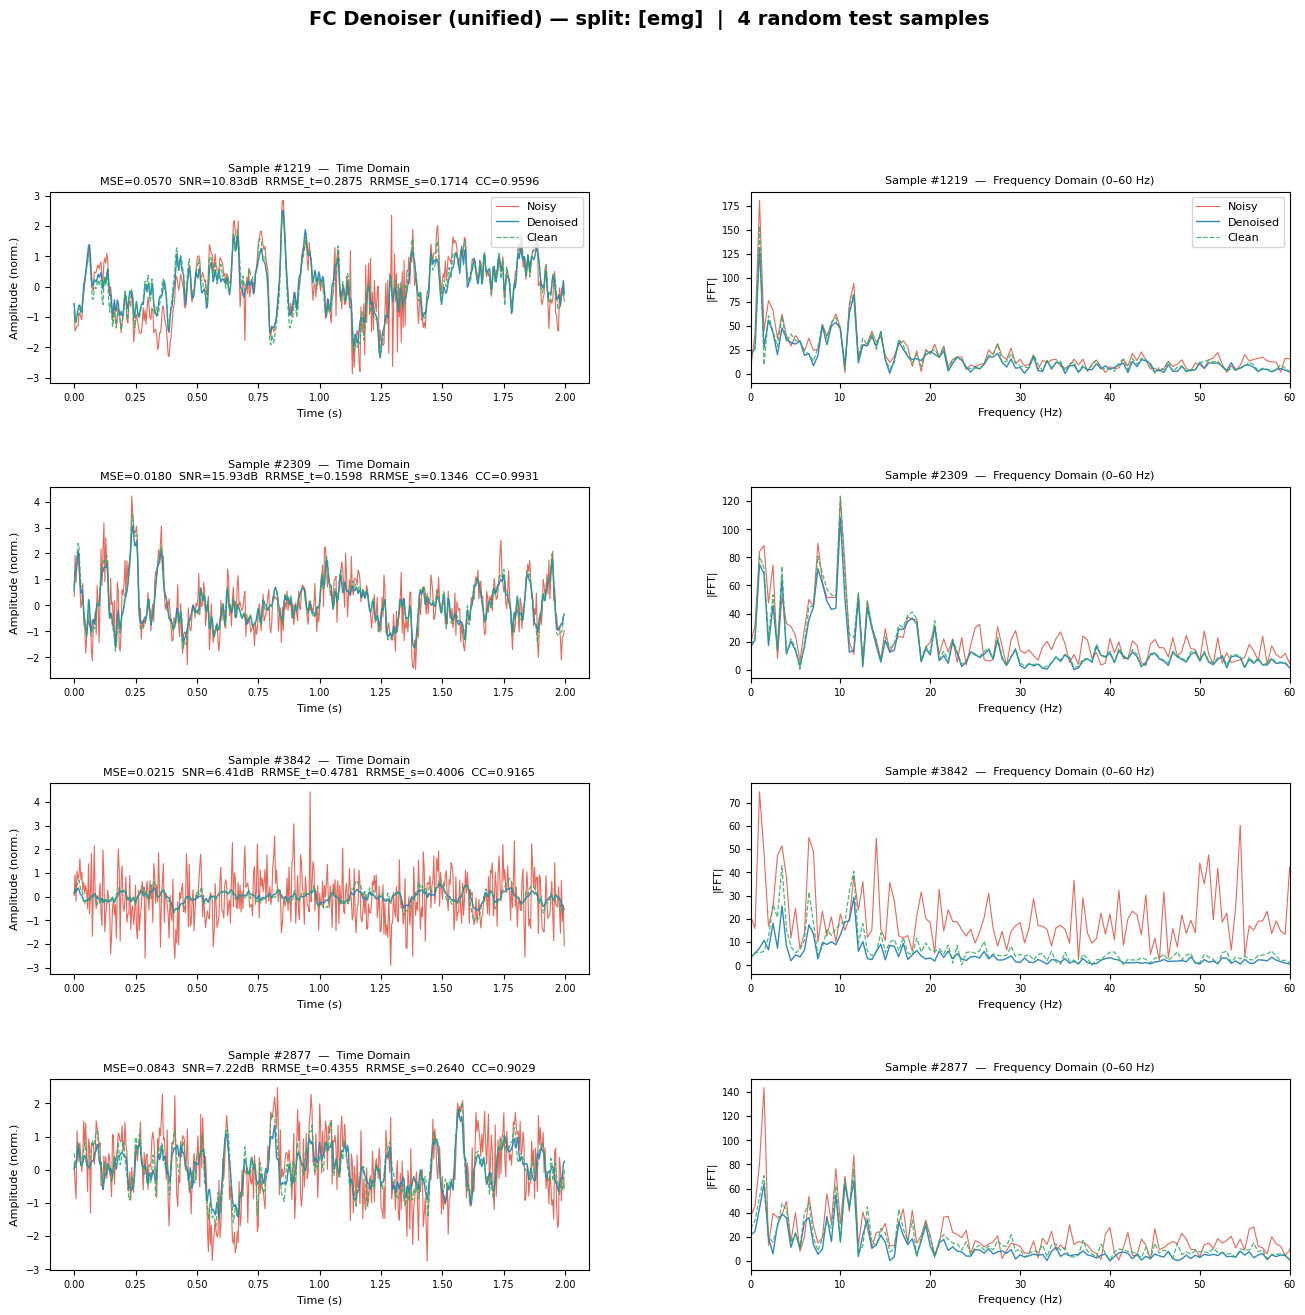


[emg]  plot saved → /kaggle/working/plots/fc_test_emg.png


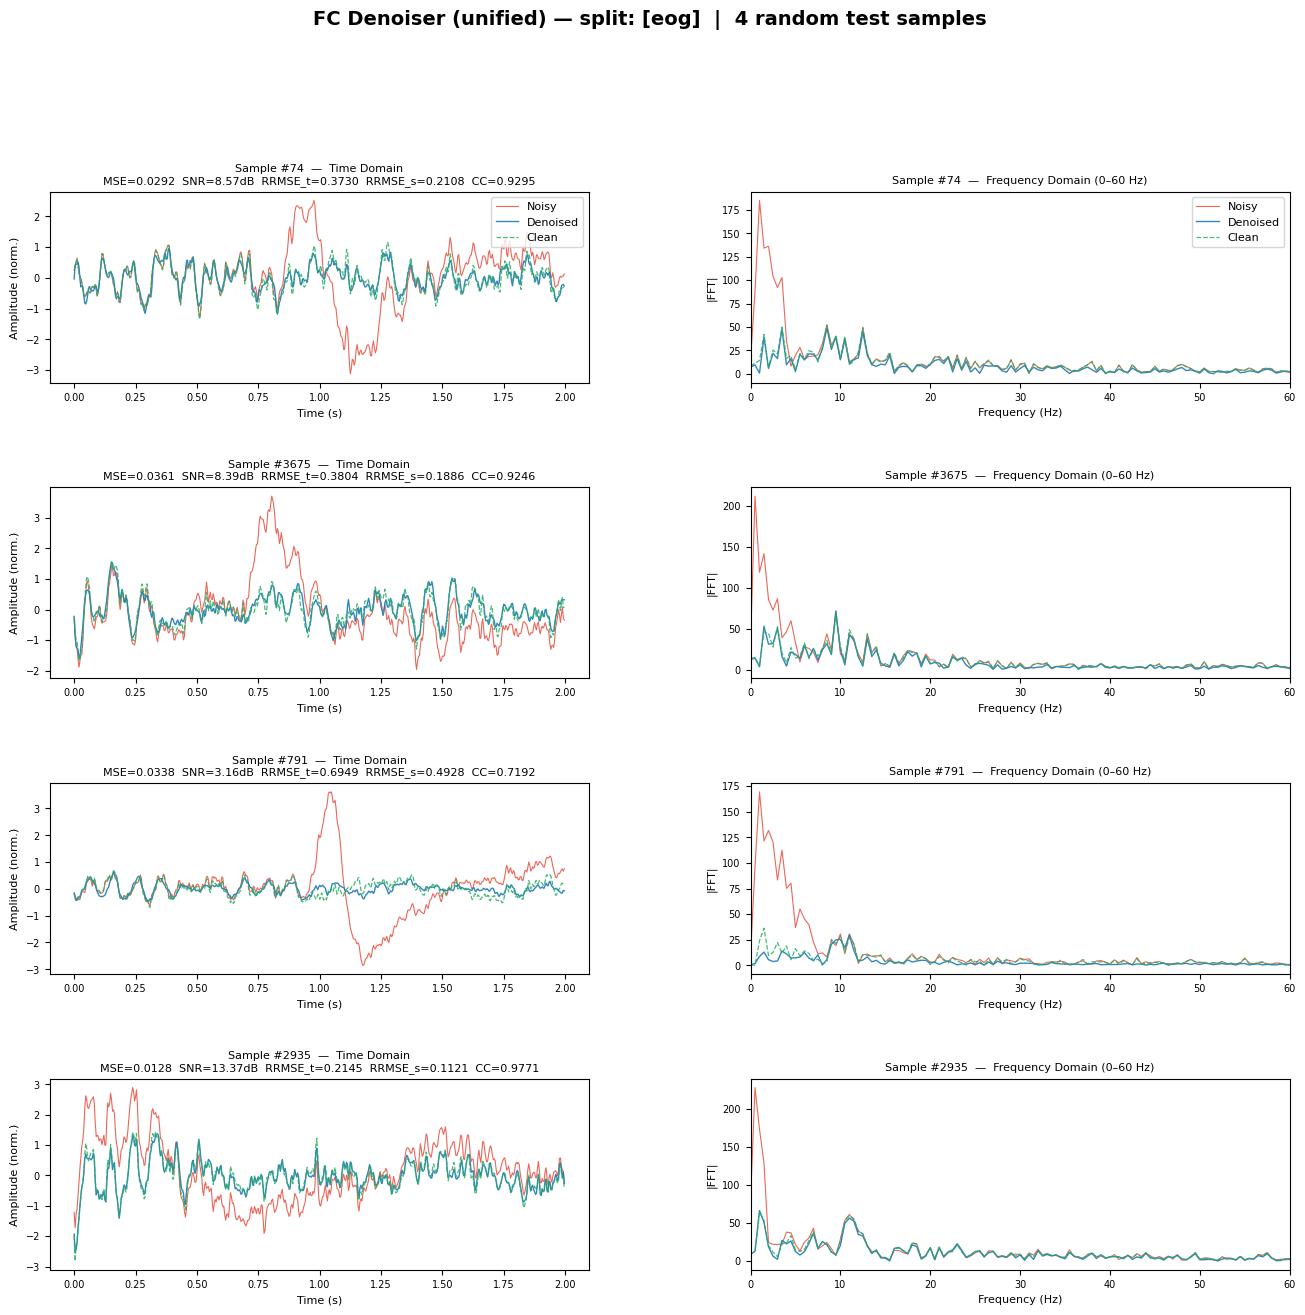


[eog]  plot saved → /kaggle/working/plots/fc_test_eog.png


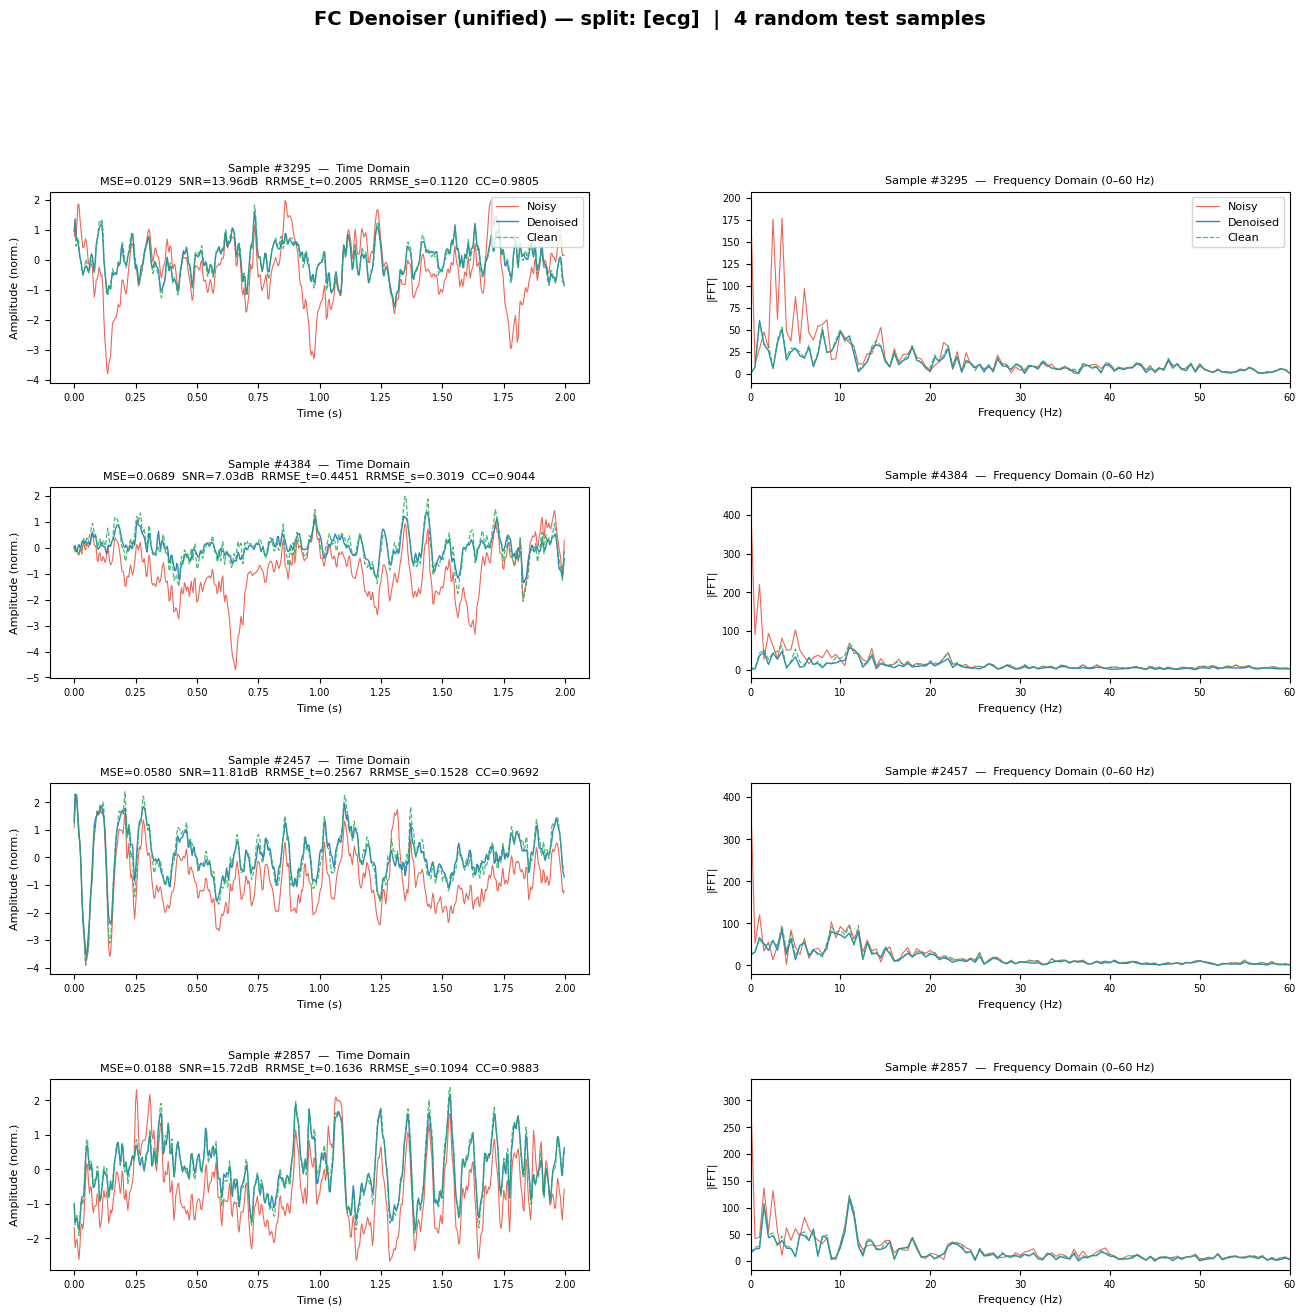


[ecg]  plot saved → /kaggle/working/plots/fc_test_ecg.png


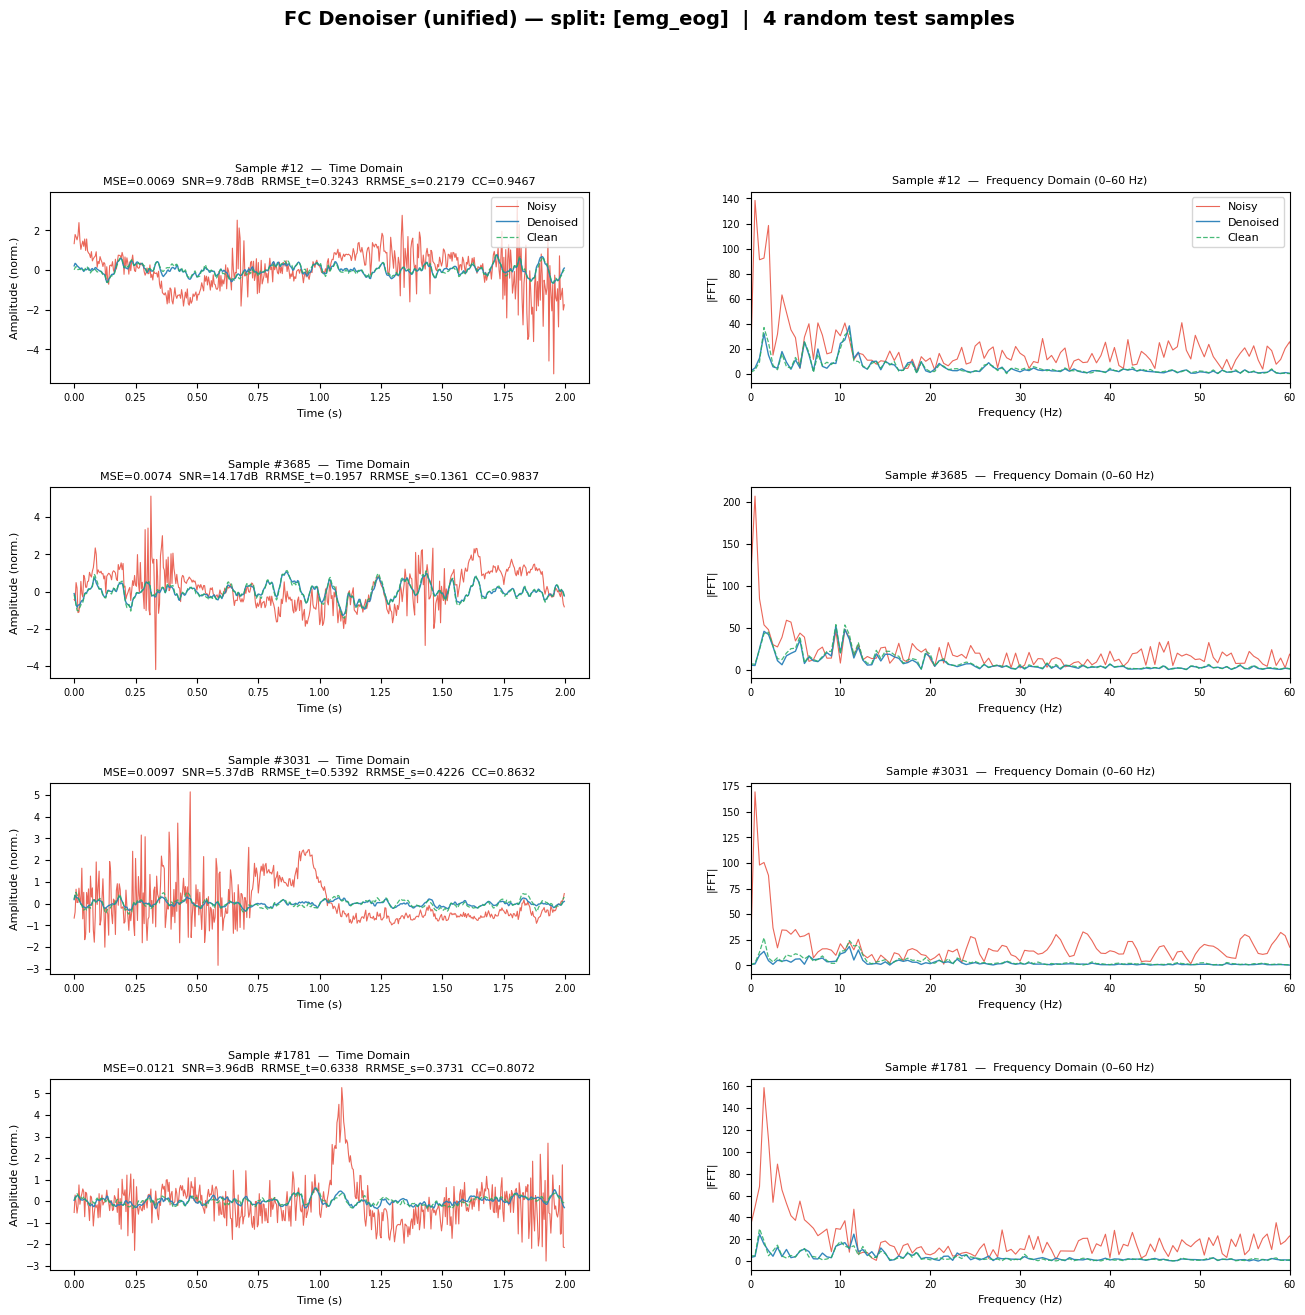


[emg_eog]  plot saved → /kaggle/working/plots/fc_test_emg_eog.png


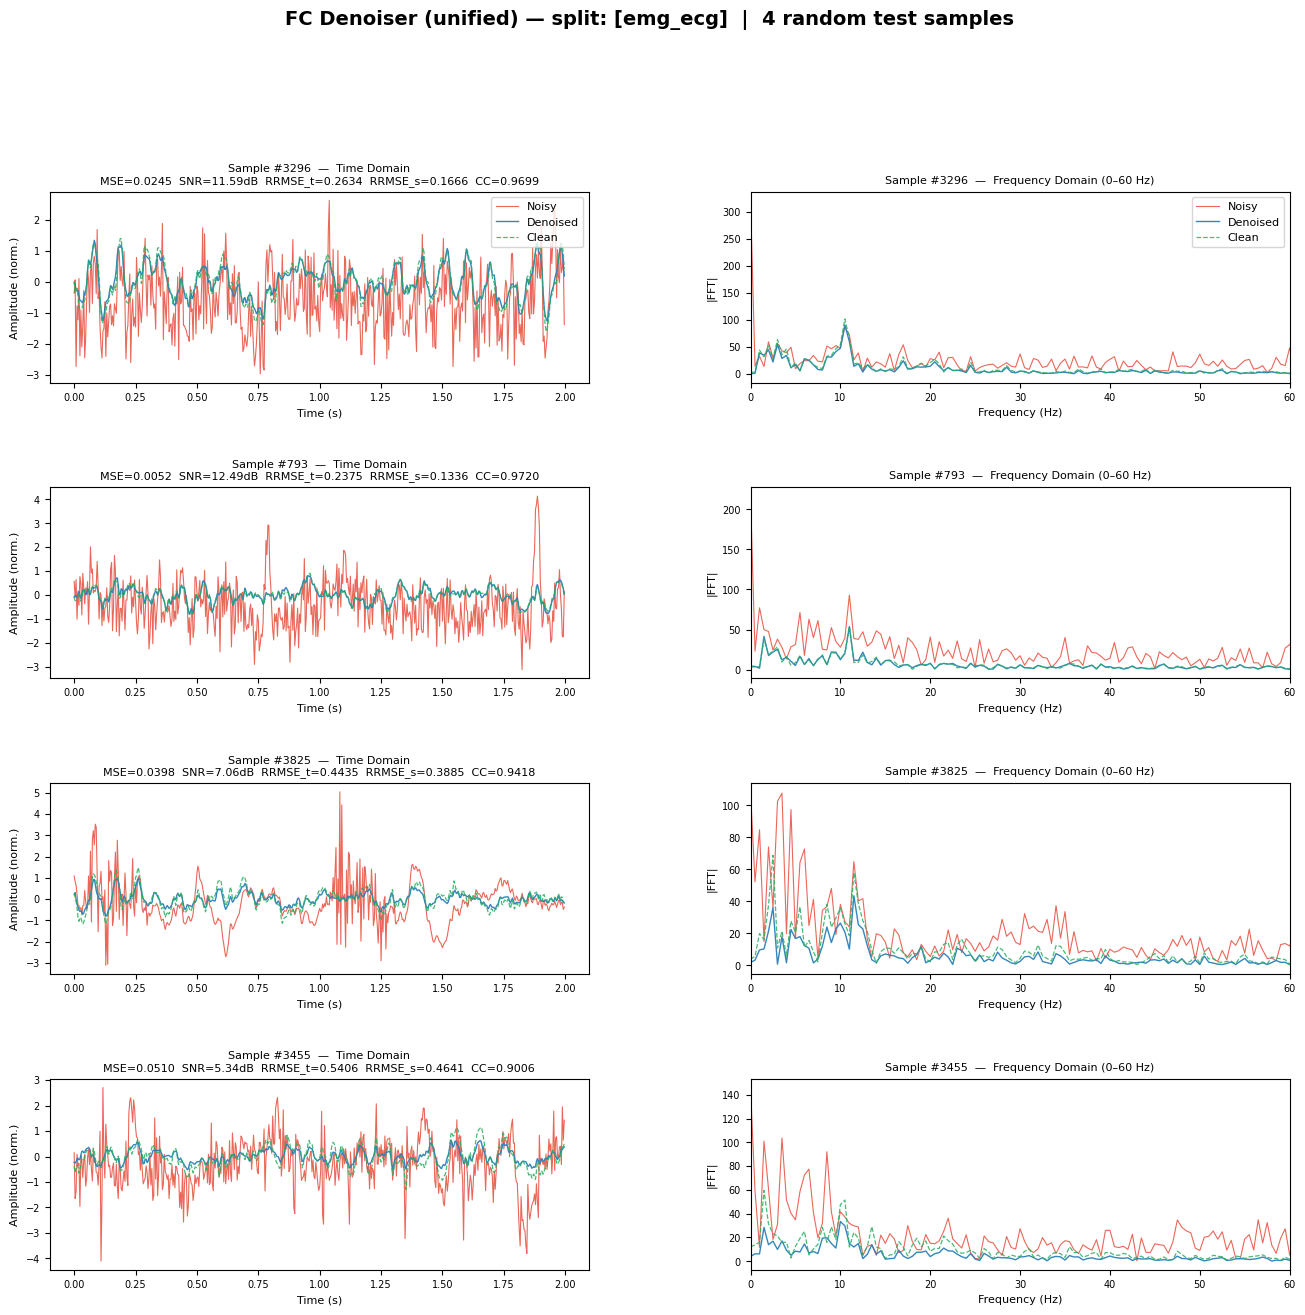


[emg_ecg]  plot saved → /kaggle/working/plots/fc_test_emg_ecg.png


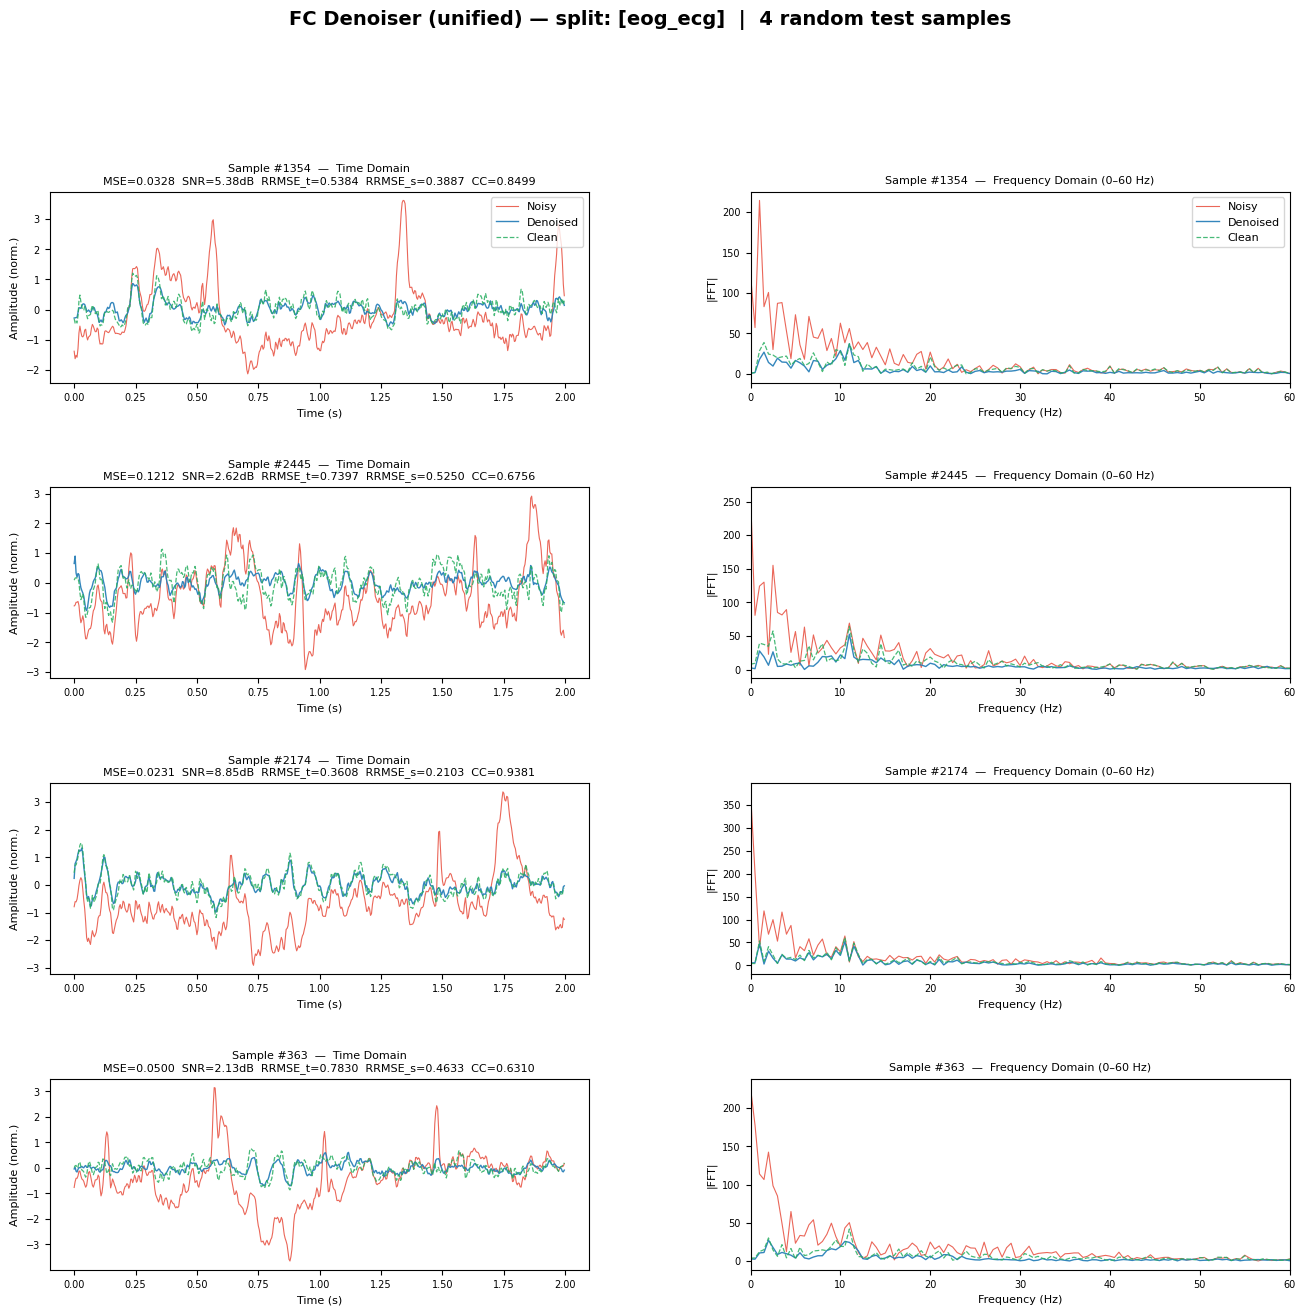


[eog_ecg]  plot saved → /kaggle/working/plots/fc_test_eog_ecg.png


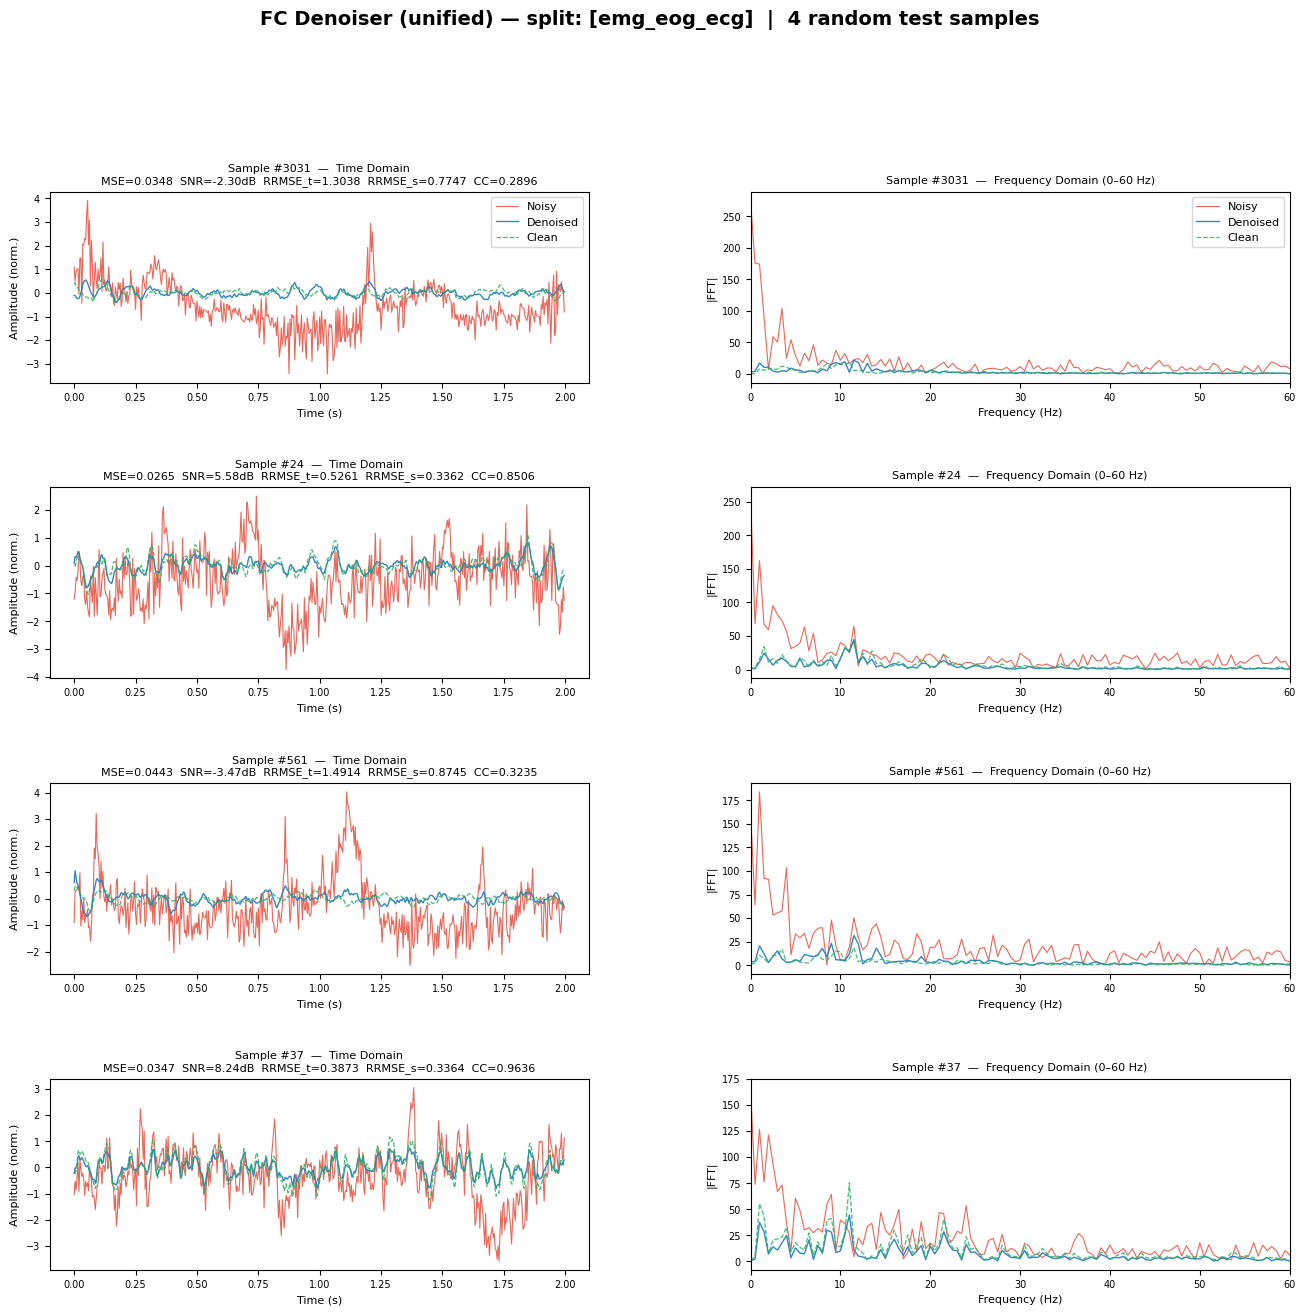


[emg_eog_ecg]  plot saved → /kaggle/working/plots/fc_test_emg_eog_ecg.png

Done. All splits visualised.


In [32]:
t_axis = np.arange(WIN_LEN) / FS   # 0 … 1.996 s
rng    = np.random.default_rng(SEED)

# Load the single unified model once
ckpt_path = os.path.join(CKPT_DIR, "fc_denoiser_all.pt")
if not os.path.exists(ckpt_path):
    print(f"Checkpoint not found: {ckpt_path}")
else:
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    cfg   = ckpt.get("model_config", {"win_len": WIN_LEN, "dropout": 0.3})
    model = FCDenoiser(**cfg).to(DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    for combo in SPLITS:
        h5_path = os.path.join(H5_DIR, f"{combo}_test.h5")

        if not os.path.exists(h5_path):
            print(f"[{combo}]  test file not found: {h5_path}  — skipping")
            continue

        # ── load test set ──
        with h5py.File(h5_path, "r") as hf:
            noisy_all = hf["noisy"][:]   # (N, 512) float32
            clean_all = hf["clean"][:]

        n_test  = len(noisy_all)
        indices = rng.choice(n_test, size=N_SAMPLES, replace=False)

        noisy_batch = torch.tensor(noisy_all[indices], dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            denoised_batch = model(noisy_batch).cpu().numpy()

        noisy_sel = noisy_all[indices]
        clean_sel = clean_all[indices]

        # ── figure: N_SAMPLES rows × 2 cols (time | spectrum) ──
        fig = plt.figure(figsize=(16, 3.5 * N_SAMPLES))
        fig.suptitle(
            f"FC Denoiser (unified) — split: [{combo}]  |  {N_SAMPLES} random test samples",
            fontsize=14, fontweight="bold", y=1.01
        )
        gs = gridspec.GridSpec(N_SAMPLES, 2, figure=fig, hspace=0.55, wspace=0.3)

        for row, (idx, noisy, denoised, clean) in enumerate(
            zip(indices, noisy_sel, denoised_batch, clean_sel)
        ):
            m = sample_metrics(denoised, clean)
            metric_str = (
                f"MSE={m['MSE']:.4f}  SNR={m['SNR']:.2f}dB  "
                f"RRMSE_t={m['RRMSE_t']:.4f}  RRMSE_s={m['RRMSE_s']:.4f}  CC={m['CC']:.4f}"
            )

            # ── left: time domain ──
            ax_t = fig.add_subplot(gs[row, 0])
            ax_t.plot(t_axis, noisy,    color="#e74c3c", lw=0.8, alpha=0.85, label="Noisy")
            ax_t.plot(t_axis, denoised, color="#2980b9", lw=1.0, alpha=0.95, label="Denoised")
            ax_t.plot(t_axis, clean,    color="#27ae60", lw=0.9, alpha=0.85,
                      linestyle="--", label="Clean")
            ax_t.set_title(f"Sample #{idx}  —  Time Domain\n{metric_str}", fontsize=8)
            ax_t.set_xlabel("Time (s)", fontsize=8)
            ax_t.set_ylabel("Amplitude (norm.)", fontsize=8)
            ax_t.tick_params(labelsize=7)
            if row == 0:
                ax_t.legend(fontsize=8, loc="upper right")

            # ── right: frequency domain ──
            freqs = np.fft.rfftfreq(WIN_LEN, d=1.0 / FS)
            ax_f  = fig.add_subplot(gs[row, 1])
            ax_f.plot(freqs, np.abs(np.fft.rfft(noisy)),    color="#e74c3c", lw=0.8, alpha=0.85, label="Noisy")
            ax_f.plot(freqs, np.abs(np.fft.rfft(denoised)), color="#2980b9", lw=1.0, alpha=0.95, label="Denoised")
            ax_f.plot(freqs, np.abs(np.fft.rfft(clean)),    color="#27ae60", lw=0.9, alpha=0.85, linestyle="--", label="Clean")
            ax_f.set_xlim(0, 60)
            ax_f.set_title(f"Sample #{idx}  —  Frequency Domain (0–60 Hz)", fontsize=8)
            ax_f.set_xlabel("Frequency (Hz)", fontsize=8)
            ax_f.set_ylabel("|FFT|", fontsize=8)
            ax_f.tick_params(labelsize=7)
            if row == 0:
                ax_f.legend(fontsize=8, loc="upper right")

        save_path = os.path.join(PLOT_DIR, f"fc_test_{combo}.png")
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print(f"\n[{combo}]  plot saved → {save_path}")

    print("\nDone. All splits visualised.")


In [33]:
import shutil

shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')

'/kaggle/working/plots.zip'